In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

grid_features = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_final_feature_set.csv")
grid_full = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_data_final_preprocessed_15min.csv")

grid_features = grid_features.reset_index(drop=True)
grid_full = grid_full.reset_index(drop=True)

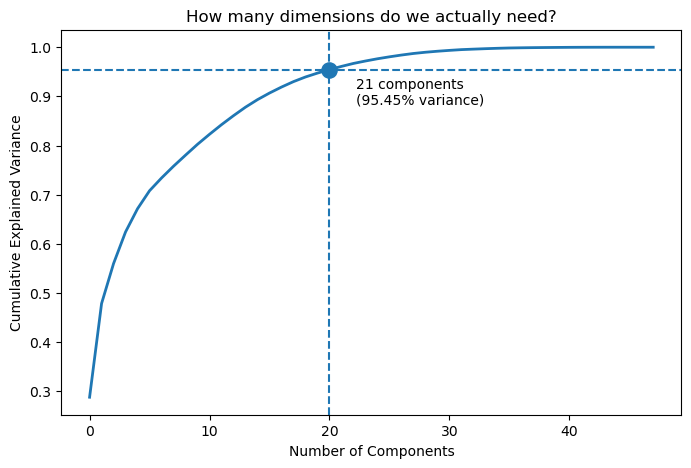

Optimal number of components: 21


In [107]:
# PCA for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(grid_features)

pca = PCA()
pca.fit(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

threshold = 0.95
n_components = np.argmax(cum_var >= threshold) + 1

plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)

plt.scatter(n_components-1, cum_var[n_components-1], s=120)
plt.axvline(n_components-1, linestyle='--')
plt.axhline(cum_var[n_components-1], linestyle='--')

plt.text(
    n_components + 1.2, 
    cum_var[n_components-1] - 0.015,
    f"{n_components} components\n({cum_var[n_components-1]*100:.2f}% variance)",
    fontsize=10,
    verticalalignment='top'
)

plt.title("How many dimensions do we actually need?")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()
print("Optimal number of components:", n_components)

In [108]:
#Using VIF for feature selection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X = grid_features.copy()
X = X.dropna()  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = list(grid_features.columns)
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(list(grid_features.columns)))]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        Feature         VIF
0                        temp_c         inf
6                 demand_avg_mw         inf
5                   wind_gen_mw         inf
4                  solar_gen_mw         inf
37                    wind_ramp         inf
38               renewable_ramp         inf
30         heating_degree_hours         inf
29         cooling_degree_hours         inf
36                   solar_ramp         inf
47                  net_load_mw         inf
15            solar_penetration  600.841165
16  total_renewable_penetration  514.276133
11                demand_lag_1h  286.703258
13              temp_rolling_3h  223.771450
20              net_load_lag_1h  118.414230
35                net_load_ramp   65.608978
21                 temp_lag_24h   56.482290
12             net_load_lag_24h   54.119254
18               demand_lag_24h   48.886396
26          temp_rolling_max_3d   42.346196
25         temp_rolling_mean_7d   38.026500
10                  demand_ramp 

In [109]:
if_features_final = [
    'net_load_ramp',
    'demand_ramp',
    'solar_ramp',
    'wind_ramp',
    'demand_volatility_6h',
    'solar_penetration',
    'heat_index_c',
    'heatwave_index',
    'humidity_pct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'demand_rolling_std_7d',
    'demand_rolling_max_24h',
    'is_weekend',
    'is_peak_hour',
    'low_ren_high_dem',
    'is_extreme_temp',
    'is_extreme_demand',
    'dhi_wm2',
]

X = grid_features[if_features_final].copy()
print(f"\nFinal dataset shape: {X.shape}")


Final dataset shape: (105216, 21)


In [110]:
# Isolation Forest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if_model = IsolationForest(
    contamination=0.05,  
    n_estimators=100,
    random_state=42,
    n_jobs=-1  
)

if_model.fit(X_scaled)
predictions = if_model.predict(X_scaled)
scores = if_model.decision_function(X_scaled)

anomalies_df = X.loc[X.index].copy()  
anomalies_df['if_anomaly_flag'] = (predictions == -1).astype(int)  
anomalies_df['if_anomaly_score'] = scores

full_df = anomalies_df.copy()
anomalies_df = anomalies_df[anomalies_df['if_anomaly_flag'] == 1].copy()

print(f"Total rows: {len(anomalies_df)}")
print(f"Anomalies found: {len(anomalies_df)}")
print(f"Percentage: {len(anomalies_df)/len(X)*100:.2f}%")

Total rows: 5261
Anomalies found: 5261
Percentage: 5.00%


In [111]:
features = [
    "demand_ramp",
    "net_load_ramp",
    "solar_ramp",
    "wind_ramp",
    "heat_index_c",
    "demand_volatility_6h"
]

normal_df = grid_full.drop(anomalies_df.index).copy()
normal_mean = normal_df[features].mean()
anomaly_mean = anomalies_df[features].mean()
comparison_df = pd.DataFrame({
    "normal_mean": normal_mean,
    "anomaly_mean": anomaly_mean
})
comparison_df["percent_change"] = (
    (comparison_df["anomaly_mean"] - comparison_df["normal_mean"])
    / comparison_df["normal_mean"].abs()
) * 100
comparison_df = comparison_df.round(2)


In [112]:
comparison_df

,normal_mean,anomaly_mean,percent_change
demand_ramp,-8.58,163.13,2000.78
net_load_ramp,-24.94,473.76,1999.49
solar_ramp,18.85,-358.06,-1999.92
wind_ramp,-9.92,188.91,2004.79
heat_index_c,30.94,29.55,-4.50
demand_volatility_6h,1514.37,2483.02,63.96


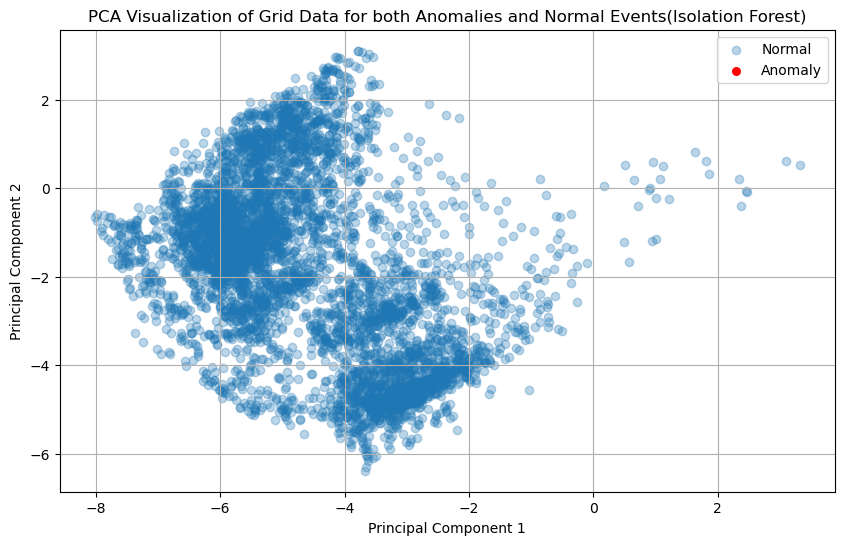

In [113]:
#PCA Scatter Plot to validate isolation forest
whole_pca = PCA(n_components=2)
whole_data_pca = whole_pca.fit_transform(X_scaled)
whole_pca_df = pd.DataFrame(whole_data_pca, columns=['PC1', 'PC2'])
whole_pca_df['anomaly'] = full_df['if_anomaly_flag'].values

plt.figure(figsize=(10, 6))

# Normal points
plt.scatter(
    whole_pca_df[whole_pca_df['anomaly'] == 1]['PC1'],
    whole_pca_df[whole_pca_df['anomaly'] == 1]['PC2'],
    label='Normal',
    alpha=0.3
)

# Anomaly points
plt.scatter(
    whole_pca_df[whole_pca_df['anomaly'] == -1]['PC1'],
    whole_pca_df[whole_pca_df['anomaly'] == -1]['PC2'],
    label='Anomaly',
    color='red',
    alpha=1,
    s=30
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Grid Data for both Anomalies and Normal Events(Isolation Forest)')
plt.legend()
plt.grid()

plt.show()

Grid stress events are not globally distinct but occur as local deviations within normal operating regimes.
Yes, anomalies exist
But they are contextual, not globally separable

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_cols = anomalies_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['if_anomaly_flag']]

X = anomalies_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['anomaly'] = anomalies_df['if_anomaly_flag'].values

In [115]:
explained_var = pca.explained_variance_ratio_

print("Explained Variance:")
print(f"PC1: {explained_var[0]:.4f}")
print(f"PC2: {explained_var[1]:.4f}")
print(f"Total: {explained_var.sum():.4f}")

pca_loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=['PC1', 'PC2']
)

print("\nTop PC1 features:")
print(pca_loadings.loc['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop PC2 features:")
print(pca_loadings.loc['PC2'].abs().sort_values(ascending=False).head(10))

Explained Variance:
PC1: 0.3456
PC2: 0.1472
Total: 0.4927

Top PC1 features:
hour_cos             0.323076
dhi_wm2              0.321256
is_peak_hour         0.310702
is_extreme_temp      0.309272
solar_penetration    0.307386
demand_ramp          0.285608
heat_index_c         0.285106
humidity_pct         0.276367
solar_ramp           0.270899
low_ren_high_dem     0.258822
Name: PC1, dtype: float64

Top PC2 features:
net_load_ramp             0.396762
demand_volatility_6h      0.349416
demand_rolling_std_7d     0.332580
hour_sin                  0.296839
heatwave_index            0.278485
solar_ramp                0.259171
demand_rolling_max_24h    0.248896
demand_ramp               0.236667
low_ren_high_dem          0.222711
wind_ramp                 0.213831
Name: PC2, dtype: float64


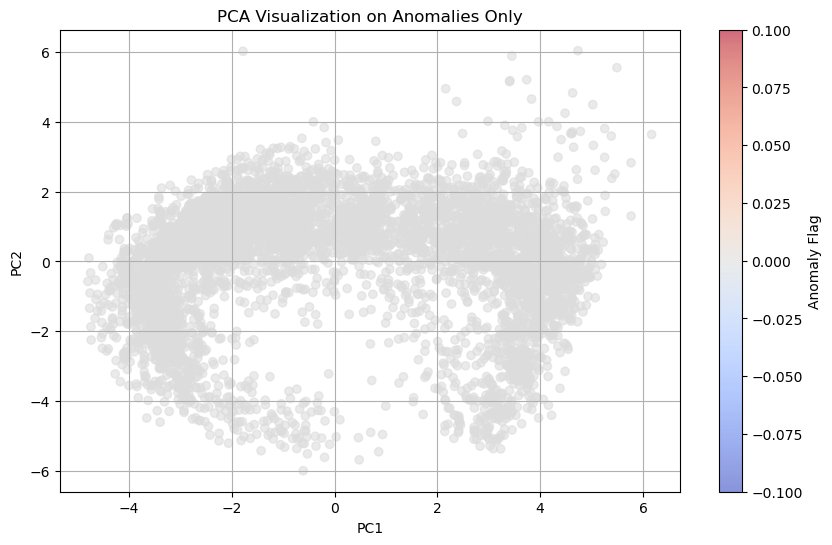

In [116]:
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['anomaly'].map({1:0, -1:1}),
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization on Anomalies Only')
plt.colorbar(label='Anomaly Flag')
plt.grid()

plt.show()

Grid data lies on a structured but nonlinear manifold governed by operational conditions and variability.

PC1 -> operating conditions (solar, temp, demand)
PC2 -> stress / ramp / volatility

PCA visualization of anomalies showed a dominant dense region along with smaller dispersed groups, indicating the presence of multiple anomaly patterns. Based on this observation, clustering was applied to categorize different types of grid stress events.

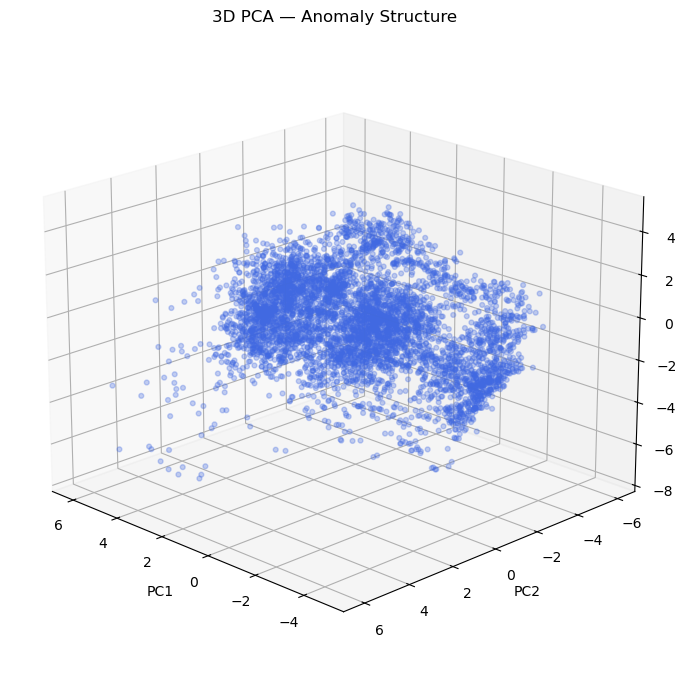

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = anomalies_df.select_dtypes(include=['number']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'if_anomaly_flag']

X = anomalies_df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_3d_df['PC1'],
    pca_3d_df['PC2'],
    pca_3d_df['PC3'],
    c='royalblue',
    alpha=0.3,
    s=12
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA — Anomaly Structure')

ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()

In [118]:
explained_var = pca_3d.explained_variance_ratio_

print("Explained Variance (Anomalies):")
print(f"PC1: {explained_var[0]:.4f}")
print(f"PC2: {explained_var[1]:.4f}")
print(f"PC3: {explained_var[2]:.4f}")
print(f"Total: {explained_var.sum():.4f}")

Explained Variance (Anomalies):
PC1: 0.3456
PC2: 0.1472
PC3: 0.1377
Total: 0.6304


In [119]:
pca_loadings = pd.DataFrame(
    pca_3d.components_,
    columns=feature_cols,
    index=['PC1', 'PC2', 'PC3']
)

print("\nTop PC1 features (Anomaly Type Axis):")
print(pca_loadings.loc['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop PC2 features (Stress Intensity Axis):")
print(pca_loadings.loc['PC2'].abs().sort_values(ascending=False).head(10))

print("\nTop PC3 features (Secondary Dynamics):")
print(pca_loadings.loc['PC3'].abs().sort_values(ascending=False).head(10))


Top PC1 features (Anomaly Type Axis):
hour_cos             0.323076
dhi_wm2              0.321256
is_peak_hour         0.310702
is_extreme_temp      0.309272
solar_penetration    0.307386
demand_ramp          0.285608
heat_index_c         0.285106
humidity_pct         0.276367
solar_ramp           0.270899
low_ren_high_dem     0.258822
Name: PC1, dtype: float64

Top PC2 features (Stress Intensity Axis):
net_load_ramp             0.396762
demand_volatility_6h      0.349416
demand_rolling_std_7d     0.332580
hour_sin                  0.296839
heatwave_index            0.278485
solar_ramp                0.259171
demand_rolling_max_24h    0.248896
demand_ramp               0.236667
low_ren_high_dem          0.222711
wind_ramp                 0.213831
Name: PC2, dtype: float64

Top PC3 features (Secondary Dynamics):
demand_rolling_max_24h    0.416818
if_anomaly_score          0.388935
demand_volatility_6h      0.338180
is_extreme_demand         0.333018
month_sin                 0.309452
d

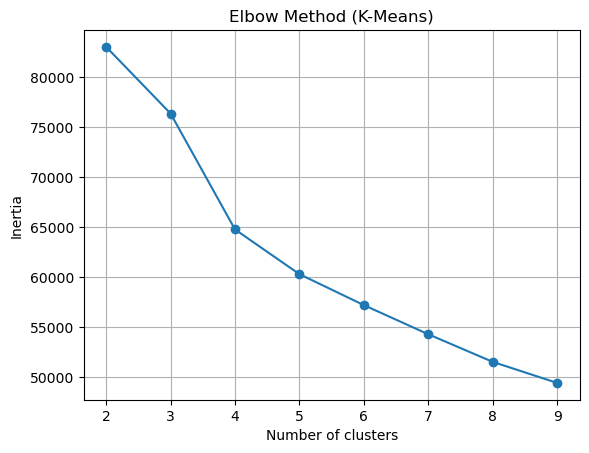

In [120]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method (K-Means)')
plt.grid()
plt.show()

In [121]:
#Applying K-Means (k = 3)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = anomalies_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['if_anomaly_flag', 'if_anomaly_score', 'cluster']]
scaler = StandardScaler()
X_anom_scaled = scaler.fit_transform(anomalies_df[feature_cols])
kmeans = KMeans(n_clusters=3, random_state=42)
anomalies_df['cluster'] = kmeans.fit_predict(X_anom_scaled)
anomalies_df['cluster'].value_counts()

cluster_summary = anomalies_df.groupby('cluster')[feature_cols].mean()
cluster_summary_df = pd.DataFrame(cluster_summary)

In [122]:
cluster_summary_df

,net_load_ramp,demand_ramp,solar_ramp,wind_ramp,demand_volatility_6h,solar_penetration,heat_index_c,heatwave_index,humidity_pct,hour_sin,...,month_sin,month_cos,demand_rolling_std_7d,demand_rolling_max_24h,is_weekend,is_peak_hour,low_ren_high_dem,is_extreme_temp,is_extreme_demand,dhi_wm2
cluster,,,,,,,,,,,,,,,,,,,,,
0,515.209125,366.966465,-219.901698,280.298071,3140.556721,0.253370,31.402677,67.721503,27.398497,-0.667800,...,-0.694003,-0.535882,5447.049856,40712.425590,0.246978,0.159758,0.044905,0.994387,0.905440,129.724180
1,685.944757,-153.398295,-890.570332,224.003922,2344.994138,0.085723,26.690949,61.044501,39.361826,-0.942594,...,-0.651467,-0.522214,5375.254977,39677.015345,0.337596,0.937084,0.726854,0.083376,0.882353,22.739983
2,-42.200000,311.354209,370.328956,-94.203367,1217.332380,0.318705,30.842264,74.275758,28.482225,0.464174,...,-0.681220,-0.493470,5717.669123,40230.310774,0.726263,0.000000,0.125253,0.921212,0.003030,181.435758


In [123]:
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(X_scaled, anomalies_df['cluster'])
print("K-Means Silhouette Score (k = 3):", round(kmeans_score, 4))

K-Means Silhouette Score (k = 3): 0.242


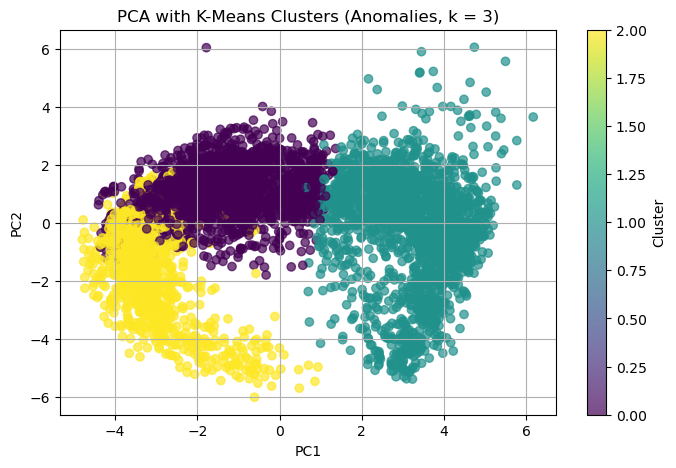

In [124]:
plt.figure(figsize=(8,5))

plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=anomalies_df['cluster'], cmap='viridis', alpha=0.7)

plt.title("PCA with K-Means Clusters (Anomalies, k = 3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.grid()

plt.show()

In [125]:
#Applying K-Means (k = 4)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = anomalies_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['if_anomaly_flag', 'if_anomaly_score', 'cluster']]
scaler = StandardScaler()
X_anom_scaled = scaler.fit_transform(anomalies_df[feature_cols])
kmeans = KMeans(n_clusters=4, random_state=42)
anomalies_df['cluster'] = kmeans.fit_predict(X_anom_scaled)
anomalies_df['cluster'].value_counts()

cluster_summary = anomalies_df.groupby('cluster')[feature_cols].mean()
cluster_summary_df = pd.DataFrame(cluster_summary)

In [126]:
cluster_summary_df

,net_load_ramp,demand_ramp,solar_ramp,wind_ramp,demand_volatility_6h,solar_penetration,heat_index_c,heatwave_index,humidity_pct,hour_sin,...,month_sin,month_cos,demand_rolling_std_7d,demand_rolling_max_24h,is_weekend,is_peak_hour,low_ren_high_dem,is_extreme_temp,is_extreme_demand,dhi_wm2
cluster,,,,,,,,,,,,,,,,,,,,,
0,513.716462,369.957821,-215.038518,277.128735,3147.100483,0.254056,31.444229,68.072056,27.296345,-0.662180,...,-0.701924,-0.529107,5465.249107,40766.378149,0.246485,0.144991,0.044815,0.994728,0.906854,130.704950
1,1015.675439,-32.436591,-1096.833083,221.319549,2585.983217,0.119464,26.635597,48.592481,38.501858,-0.981230,...,-0.575919,-0.567310,5009.387102,38163.965163,0.288722,0.984962,0.572932,0.067669,0.848120,31.074486
2,-44.068966,311.722110,371.776538,-92.081812,1214.681290,0.319669,30.851268,74.229209,28.427647,0.463014,...,-0.680334,-0.493951,5715.964887,40220.553414,0.725152,0.000000,0.122718,0.923935,0.003043,181.767748
3,23.697060,-370.702541,-451.551071,238.459392,1888.367461,0.026308,26.952897,85.153961,40.719103,-0.858353,...,-0.778737,-0.455550,6049.551849,42581.067763,0.434978,0.840060,0.992526,0.168909,0.941704,9.690184


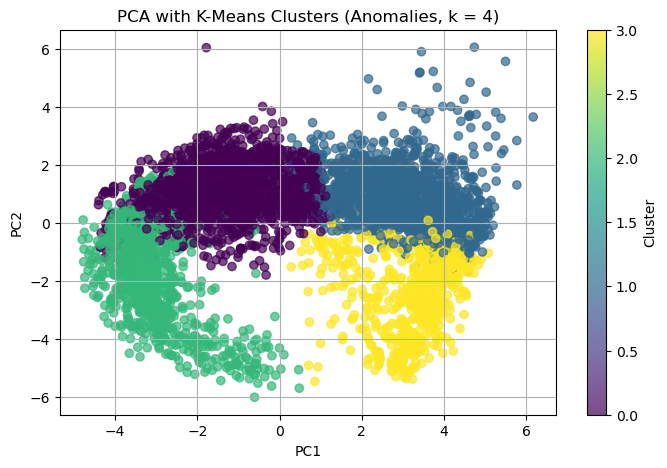

In [127]:
plt.figure(figsize=(8,5))

plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=anomalies_df['cluster'], cmap='viridis', alpha=0.7)

plt.title("PCA with K-Means Clusters (Anomalies, k = 4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.grid()

plt.show()

In [128]:
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(X_scaled, anomalies_df['cluster'])
print("K-Means Silhouette Score (k = 4):", round(kmeans_score, 4))

K-Means Silhouette Score (k = 4): 0.2148


Visible Clusters but not spherical and overlapping as well

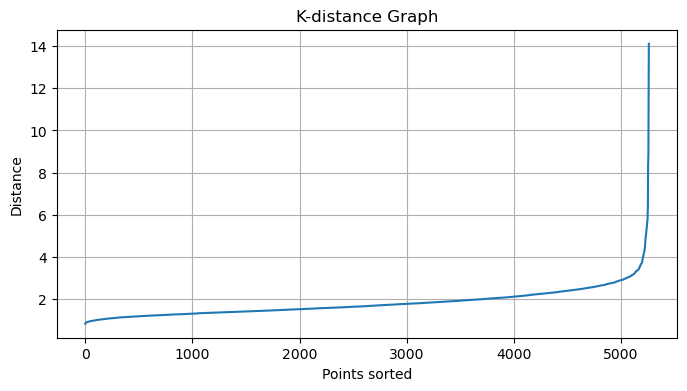

In [129]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Choose k = min_samples
k = 10

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.grid()
plt.show()

In [130]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = anomalies_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'if_anomaly_flag']

X = anomalies_df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for eps in [2.5, 2.8, 3.0, 3.2]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\neps = {eps}")
    print("Clusters:", n_clusters)
    print("Noise points:", n_noise)

    if n_clusters > 1:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        print("Silhouette Score:", round(score, 4))
    else:
        print("Silhouette Score: Not valid (<=1 cluster)")





eps = 2.5
Clusters: 10
Noise points: 247
Silhouette Score: 0.0304

eps = 2.8
Clusters: 1
Noise points: 115
Silhouette Score: Not valid (<=1 cluster)

eps = 3.0
Clusters: 2
Noise points: 66
Silhouette Score: 0.3855

eps = 3.2
Clusters: 1
Noise points: 57
Silhouette Score: Not valid (<=1 cluster)


dbscan_cluster
 0    5189
-1      66
 1       6
Name: count, dtype: int64


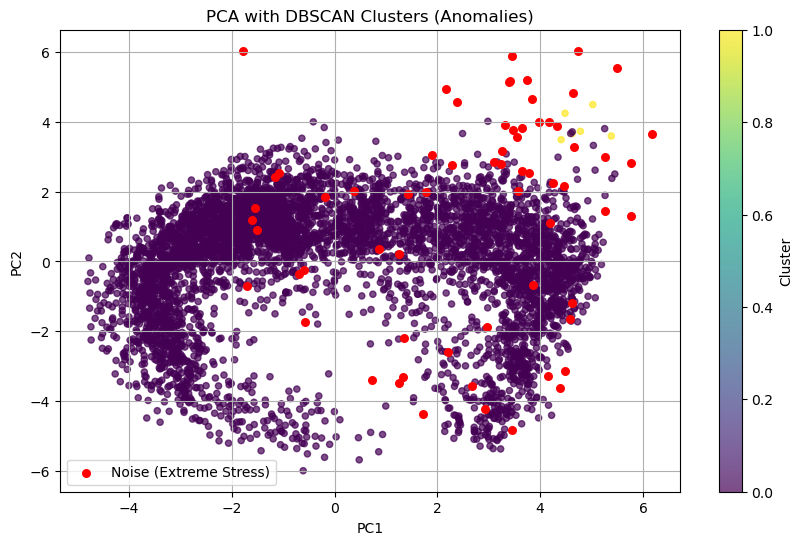

In [132]:
import matplotlib.pyplot as plt
import numpy as np

eps_value = 3.0  
dbscan = DBSCAN(eps=eps_value, min_samples=10)

anomalies_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(anomalies_df['dbscan_cluster'].value_counts())

pca_df['dbscan_cluster'] = anomalies_df['dbscan_cluster'].values

plt.figure(figsize=(10,6))

# Plot clusters (excluding noise)
clusters = pca_df[pca_df['dbscan_cluster'] != -1]

scatter = plt.scatter(
    clusters['PC1'],
    clusters['PC2'],
    c=clusters['dbscan_cluster'],
    cmap='viridis',
    alpha=0.7,
    s=20
)

# Plot noise separately (important!)
noise = pca_df[pca_df['dbscan_cluster'] == -1]

plt.scatter(
    noise['PC1'],
    noise['PC2'],
    c='red',
    s=30,
    label='Noise (Extreme Stress)'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA with DBSCAN Clusters (Anomalies)')

plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid()

plt.show()